In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = '/content/drive/MyDrive/Parkinson/parkinsons.csv'
df = pd.read_csv(file_path)


# EDA (Exploratory Data Analysis)

In [ ]:

print(df.head())




             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

In [ ]:

print(df.describe())



       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count   195.000000    195.000000    195.000000      195.000000   
mean    154.228641    197.104918    116.324631        0.006220   
std      41.390065     91.491548     43.521413        0.004848   
min      88.333000    102.145000     65.476000        0.001680   
25%     117.572000    134.862500     84.291000        0.003460   
50%     148.790000    175.829000    104.315000        0.004940   
75%     182.769000    224.205500    140.018500        0.007365   
max     260.105000    592.030000    239.170000        0.033160   

       MDVP:Jitter(Abs)    MDVP:RAP    MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
count        195.000000  195.000000  195.000000  195.000000    195.000000   
mean           0.000044    0.003306    0.003446    0.009920      0.029709   
std            0.000035    0.002968    0.002759    0.008903      0.018857   
min            0.000007    0.000680    0.000920    0.002040      0.009540   
25%            0.000

In [ ]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

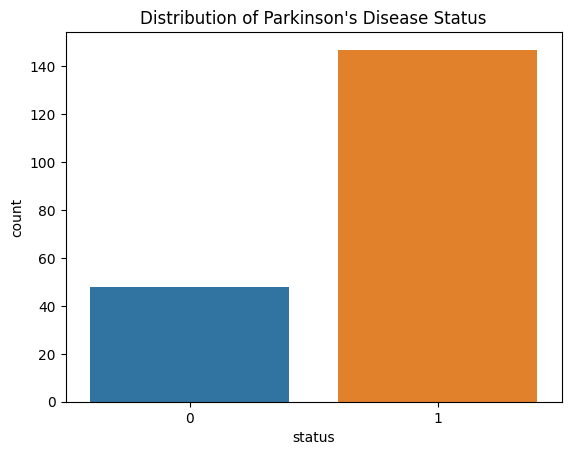

In [ ]:
sns.countplot(x='status', data=df)
plt.title('Distribution of Parkinson\'s Disease Status')
plt.show()

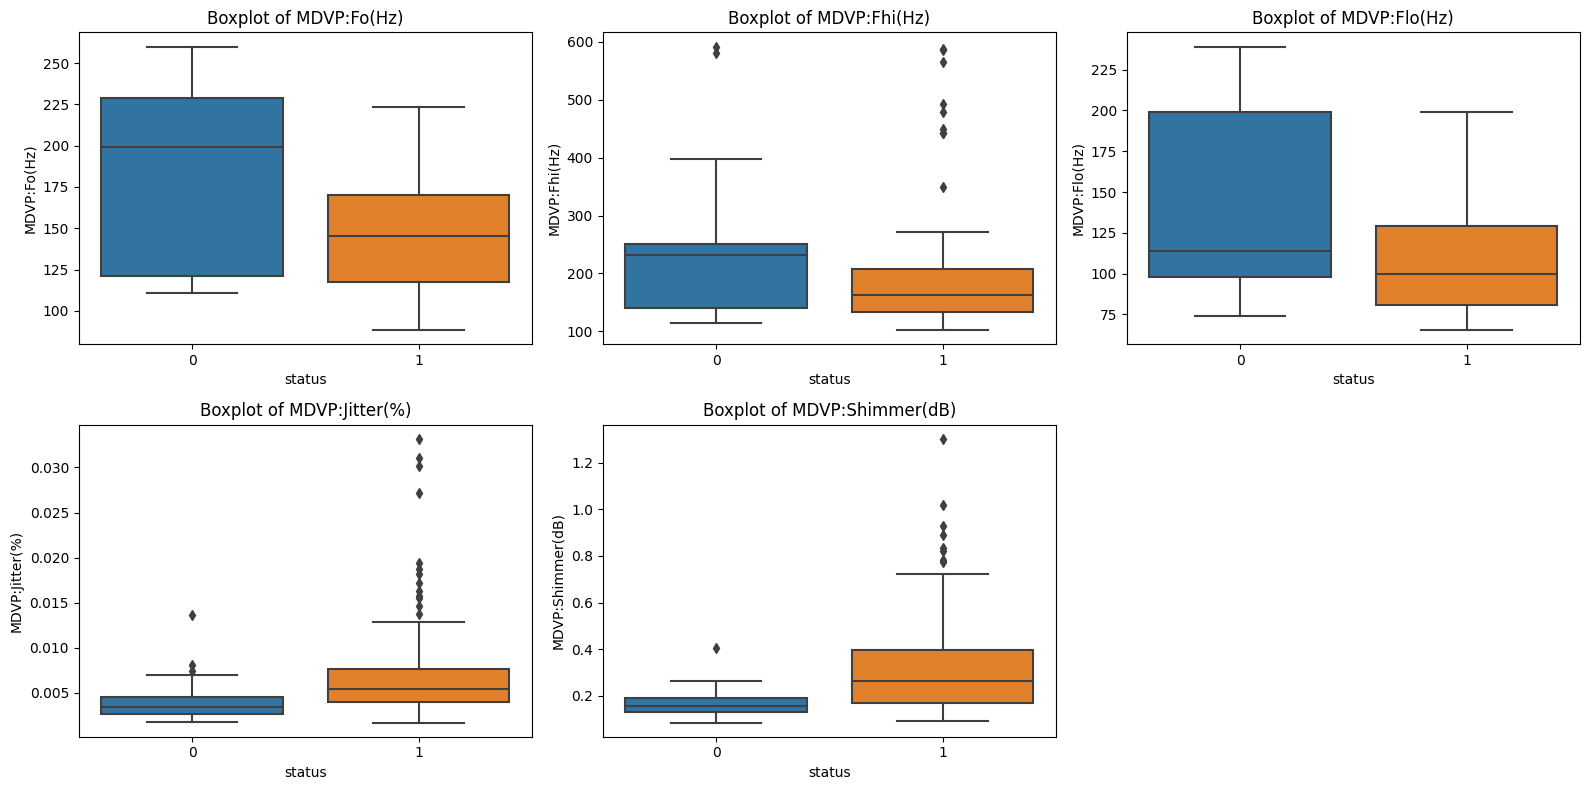

In [ ]:

selected_features = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer(dB)']
plt.figure(figsize=(16, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='status', y=feature, data=df)
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()




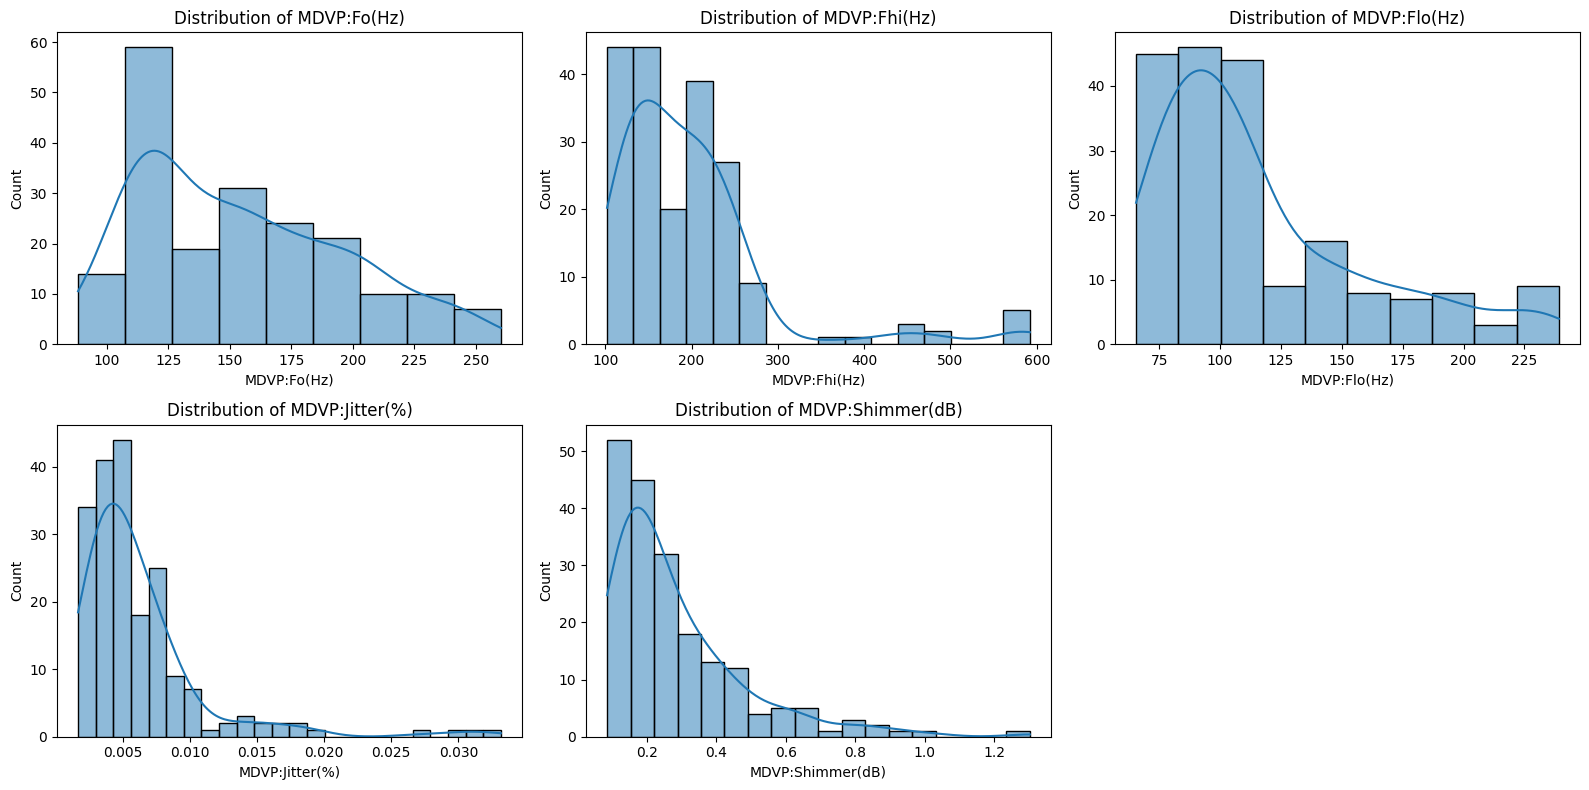

In [ ]:

plt.figure(figsize=(16, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()



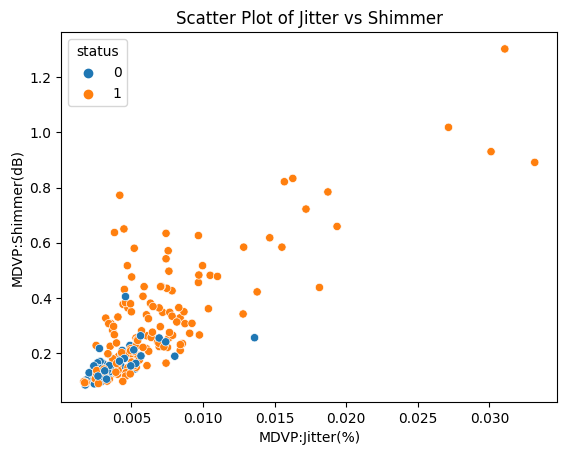

In [ ]:

sns.scatterplot(x='MDVP:Jitter(%)', y='MDVP:Shimmer(dB)', hue='status', data=df)
plt.title('Scatter Plot of Jitter vs Shimmer')
plt.show()



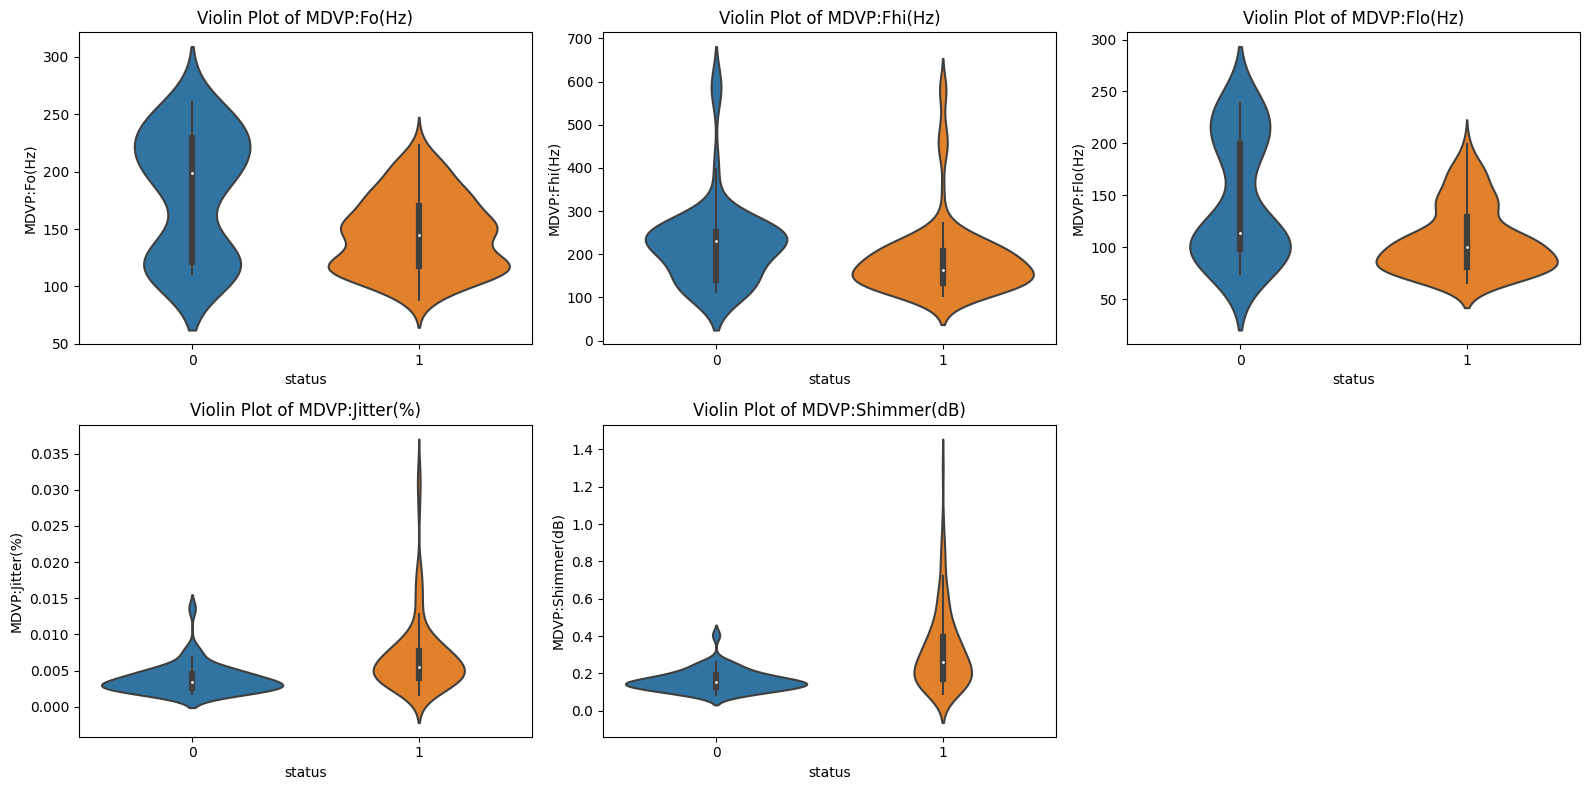

In [ ]:

plt.figure(figsize=(16, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(x='status', y=feature, data=df)
    plt.title(f'Violin Plot of {feature}')

plt.tight_layout()
plt.show()

<ipython-input-64-164267f5329f>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


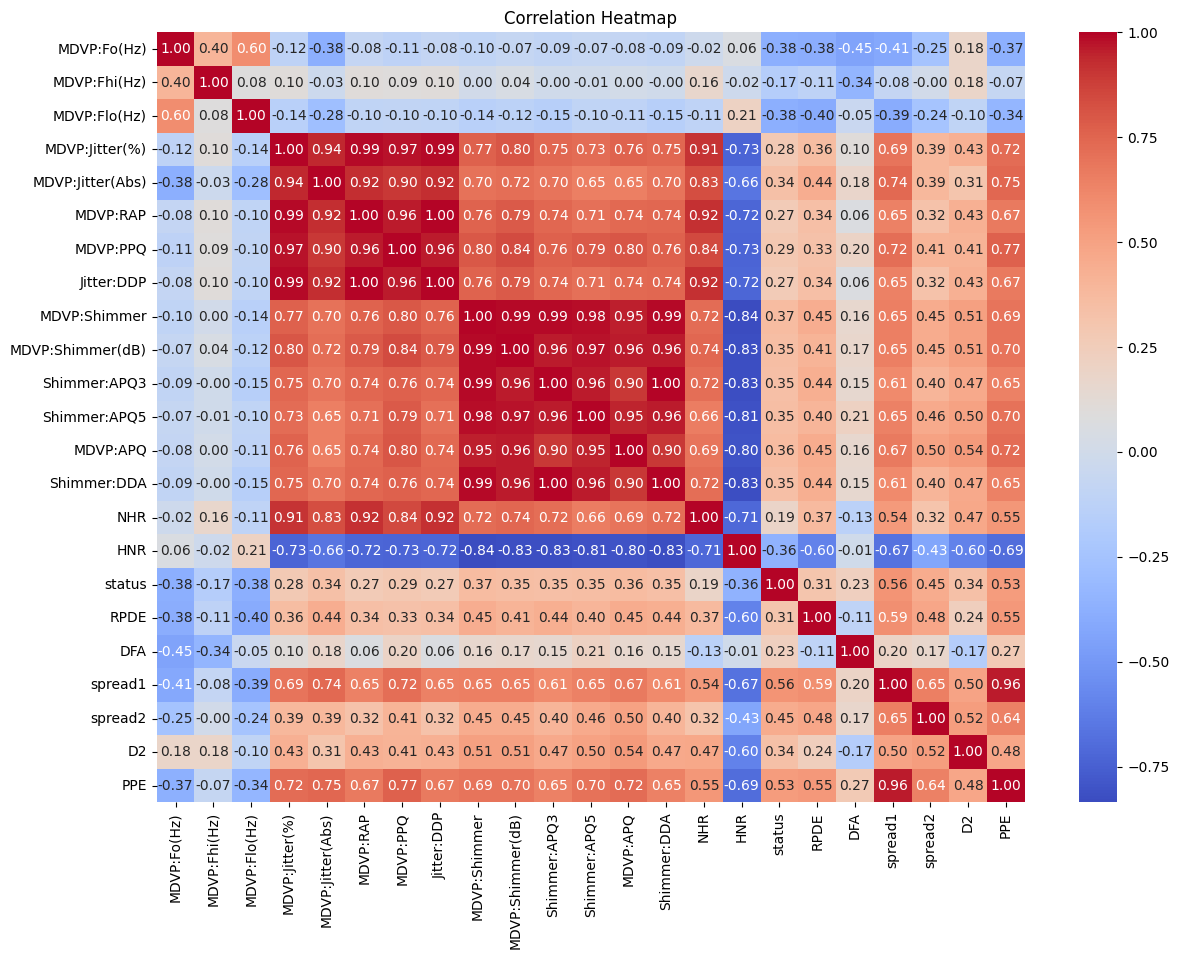

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Pre-processing

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.drop('name', axis=1)


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)


In [ ]:

print("X_train_scaled:")
print(X_train_scaled_df.head())




X_train_scaled:
   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0    -0.801729     -0.708305     -0.106033        0.682896          0.998633   
1    -1.043742     -0.749504     -0.299199       -0.225731         -0.083783   
2    -0.379050      0.131225     -0.820394        0.176825          0.186821   
3     2.542534      0.843562      2.791952       -0.522856         -0.895595   
4     0.646326      0.091813      0.872538       -0.394422         -0.624991   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0  0.429499  1.358765    0.428359      0.852202          0.820883  ...   
1 -0.255150 -0.095998   -0.256283      0.563407          0.448116  ...   
2  0.251303  0.181577    0.251206      0.740313          0.748266  ...   
3 -0.377074 -0.527411   -0.376121     -0.493996         -0.432971  ...   
4 -0.330180 -0.333442   -0.331312      0.424302          0.215741  ...   

   MDVP:APQ  Shimmer:DDA       NHR       HNR      RPDE    

In [ ]:
print("\nX_test_scaled:")
print(X_test_scaled_df.head())


X_test_scaled:
   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0    -1.000942     -0.761130     -0.333431       -0.267904         -0.083783   
1    -0.235313      1.822086     -0.833908       -0.129885         -0.083783   
2    -0.866000     -0.752544     -0.531477        0.067560          0.186821   
3     0.122423     -0.270313      0.621865       -0.517105         -0.624991   
4    -0.251010     -0.348024     -1.231713        0.937848          0.998633   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0 -0.273908 -0.179605   -0.272956      1.326975          1.116193  ...   
1 -0.358317 -0.172917   -0.359448     -0.485428         -0.457177  ...   
2  0.094990 -0.146162    0.093853      0.038737         -0.050522  ...   
3 -0.461483 -0.534099   -0.460529      0.186915          0.099554  ...   
4  1.004729  0.412333    1.004625      1.196438          0.927388  ...   

   MDVP:APQ  Shimmer:DDA       NHR       HNR      RPDE    

In [ ]:

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Missing values in X_train_scaled:")
print(X_train_scaled_df.isnull().sum())


Missing values in X_train_scaled:
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])

print("\nX_train_pca:")
print(X_train_pca_df.head())

print("\nX_test_pca:")
print(X_test_pca_df.head())



X_train_pca:
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
0  2.933879 -1.752497  1.521729 -1.669902 -0.490507  0.658350  0.246861   
1  1.524844 -1.383883 -1.755341 -0.275937  0.546181 -0.683824  0.266410   
2  1.560898 -0.432044  0.097783 -0.058836  1.668091  0.896652  0.072455   
3 -2.816303  3.860842  0.017607 -0.412921  0.729837 -1.333103  1.286487   
4  0.967189  0.597274 -2.181223 -1.301150 -0.505051 -0.680150  0.065043   

       PC_8  
0 -0.670389  
1  0.535358  
2 -0.471673  
3 -0.213885  
4  0.400608  

X_test_pca:
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
0  2.372849 -1.012559 -1.809748 -0.953795  1.888864 -0.277380  0.350251   
1 -0.835506  0.184280 -1.191235  1.970102 -0.489229  0.905814  0.935699   
2  0.693386 -1.201750 -0.845556  1.322171  0.340453 -0.943578 -0.184215   
3 -1.028176  0.866648 -0.243108 -1.087978  0.511859  0.038861 -0.786714   
4  2.616722 -0.033033  0.999272  0.497839  2.066245  0.681180 -

# SVM Model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score



svm_model = SVC(kernel='linear', random_state=random_state)

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)



Accuracy: 0.87

Confusion Matrix:
[[ 4  3]
 [ 2 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.57      0.62         7
           1       0.91      0.94      0.92        32

    accuracy                           0.87        39
   macro avg       0.79      0.75      0.77        39
weighted avg       0.87      0.87      0.87        39



# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)


y_pred_rf = rf_model.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")


conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

print("\nRandom Forest Classification Report:")
print(class_report_rf)


Random Forest Accuracy: 0.95

Random Forest Confusion Matrix:
[[ 5  2]
 [ 0 32]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



# K-Nearest Neighbors Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier()


knn_model.fit(X_train_scaled, y_train)


y_pred_knn = knn_model.predict(X_test_scaled)


accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.2f}")


conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)

print("\nK-Nearest Neighbors Confusion Matrix:")
print(conf_matrix_knn)

print("\nK-Nearest Neighbors Classification Report:")
print(class_report_knn)


K-Nearest Neighbors Accuracy: 0.95

K-Nearest Neighbors Confusion Matrix:
[[ 5  2]
 [ 0 32]]

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



# Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)


y_pred_lr = lr_model.predict(X_test_scaled)


accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")


conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
class_report_lr = classification_report(y_test, y_pred_lr)

print("\nLogistic Regression Confusion Matrix:")
print(conf_matrix_lr)

print("\nLogistic Regression Classification Report:")
print(class_report_lr)


Logistic Regression Accuracy: 0.90

Logistic Regression Confusion Matrix:
[[ 3  4]
 [ 0 32]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



# Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")

conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt)

print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dt)

print("\nDecision Tree Classification Report:")
print(class_report_dt)


Decision Tree Accuracy: 0.92

Decision Tree Confusion Matrix:
[[ 5  2]
 [ 1 31]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39



# Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.2f}")

conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb)

print("\nGradient Boosting Confusion Matrix:")
print(conf_matrix_gb)

print("\nGradient Boosting Classification Report:")
print(class_report_gb)


Gradient Boosting Accuracy: 0.92

Gradient Boosting Confusion Matrix:
[[ 5  2]
 [ 1 31]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39



# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

if 'name' in df.columns:
    df = df.drop('name', axis=1)
else:
    print("'name' column not found in DataFrame.")


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
model.add(Dense(units=1, activation='sigmoid'))


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_train_reshaped, y_train, epochs=100, batch_size=8, validation_split=0.2)

y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)


y_test = np.array(y_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


'name' column not found in DataFrame.


Epoch 1/100
16/16 [==============================] - 3s 31ms/step - loss: 0.6797 - accuracy: 0.6452 - val_loss: 0.6393 - val_accuracy: 0.7812
Epoch 2/100
16/16 [==============================] - 0s 7ms/step - loss: 0.6173 - accuracy: 0.7661 - val_loss: 0.5661 - val_accuracy: 0.7812
Epoch 3/100
16/16 [==============================] - 0s 7ms/step - loss: 0.5667 - accuracy: 0.7823 - val_loss: 0.5208 - val_accuracy: 0.7812
Epoch 4/100
16/16 [==============================] - 0s 6ms/step - loss: 0.5230 - accuracy: 0.7823 - val_loss: 0.4858 - val_accuracy: 0.7500
Epoch 5/100
16/16 [==============================] - 0s 7ms/step - loss: 0.4846 - accuracy: 0.7742 - val_loss: 0.4587 - val_accuracy: 0.7500
Epoch 6/100
16/16 [==============================] - 0s 8ms/step - loss: 0.4483 - accuracy: 0.7742 - val_loss: 0.4363 - val_accuracy: 0.7500
Epoch 7/100
16/16 [==============================] - 0s 8ms/step - loss: 0.4203 - accuracy: 0.8065 - val_loss: 0.4125 - val_accuracy: 0.7812
Epoch 8/100


# BiLSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional


if 'name' in df.columns:
    df = df.drop('name', axis=1)
else:
    print("'name' column not found in DataFrame.")


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


model = Sequential()
model.add(Bidirectional(LSTM(units=50, activation='relu'), input_shape=(1, X_train_scaled.shape[1])))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_reshaped, y_train, epochs=100, batch_size=8, validation_split=0.2)

y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = np.array(y_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


'name' column not found in DataFrame.
Epoch 1/100
16/16 [==============================] - 3s 29ms/step - loss: 0.6817 - accuracy: 0.4516 - val_loss: 0.6410 - val_accuracy: 0.7500
Epoch 2/100
16/16 [==============================] - 0s 8ms/step - loss: 0.6067 - accuracy: 0.7097 - val_loss: 0.5626 - val_accuracy: 0.7812
Epoch 3/100
16/16 [==============================] - 0s 9ms/step - loss: 0.5433 - accuracy: 0.7419 - val_loss: 0.5019 - val_accuracy: 0.7812
Epoch 4/100
16/16 [==============================] - 0s 7ms/step - loss: 0.4906 - accuracy: 0.7581 - val_loss: 0.4565 - val_accuracy: 0.7500
Epoch 5/100
16/16 [==============================] - 0s 7ms/step - loss: 0.4439 - accuracy: 0.7823 - val_loss: 0.4189 - val_accuracy: 0.7812
Epoch 6/100
16/16 [==============================] - 0s 7ms/step - loss: 0.4041 - accuracy: 0.8306 - val_loss: 0.3897 - val_accuracy: 0.8750
Epoch 7/100
16/16 [==============================] - 0s 7ms/step - loss: 0.3729 - accuracy: 0.8790 - val_loss: 0.37

# CNN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense


if 'name' in df.columns:
    df = df.drop('name', axis=1)
else:
    print("'name' column not found in DataFrame.")


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))


model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_train_reshaped, y_train, epochs=100, batch_size=16, validation_split=0.2)

y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = np.array(y_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


'name' column not found in DataFrame.
Epoch 1/100
8/8 [==============================] - 2s 28ms/step - loss: 0.7177 - accuracy: 0.3790 - val_loss: 0.6459 - val_accuracy: 0.7188
Epoch 2/100
8/8 [==============================] - 0s 6ms/step - loss: 0.6113 - accuracy: 0.7419 - val_loss: 0.5216 - val_accuracy: 0.7812
Epoch 3/100
8/8 [==============================] - 0s 6ms/step - loss: 0.5454 - accuracy: 0.8548 - val_loss: 0.4562 - val_accuracy: 0.8125
Epoch 4/100
8/8 [==============================] - 0s 6ms/step - loss: 0.4970 - accuracy: 0.8387 - val_loss: 0.4193 - val_accuracy: 0.8125
Epoch 5/100
8/8 [==============================] - 0s 6ms/step - loss: 0.4595 - accuracy: 0.8629 - val_loss: 0.3962 - val_accuracy: 0.8125
Epoch 6/100
8/8 [==============================] - 0s 6ms/step - loss: 0.4261 - accuracy: 0.9032 - val_loss: 0.3799 - val_accuracy: 0.8125
Epoch 7/100
8/8 [==============================] - 0s 6ms/step - loss: 0.4018 - accuracy: 0.8952 - val_loss: 0.3678 - val_accur

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.2f}")

conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
print("\nNaive Bayes Confusion Matrix:")
print(conf_matrix_nb)

class_report_nb = classification_report(y_test, y_pred_nb)
print("\nNaive Bayes Classification Report:")
print(class_report_nb)


Naive Bayes Accuracy: 0.72

Naive Bayes Confusion Matrix:
[[ 4  3]
 [ 8 24]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.57      0.42         7
           1       0.89      0.75      0.81        32

    accuracy                           0.72        39
   macro avg       0.61      0.66      0.62        39
weighted avg       0.79      0.72      0.74        39



# CNN+GRU

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, GRU, LSTM


if 'name' in df.columns:
    df = df.drop('name', axis=1)
else:
    print("'name' column not found in DataFrame.")

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

model.add(GRU(units=64, activation='relu', return_sequences=True))

model.add(Flatten())

model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_reshaped, y_train, epochs=100, batch_size=16, validation_split=0.2)

y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = np.array(y_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


'name' column not found in DataFrame.


Epoch 1/100
8/8 [==============================] - 2s 53ms/step - loss: 0.6679 - accuracy: 0.5887 - val_loss: 0.5697 - val_accuracy: 0.7812
Epoch 2/100
8/8 [==============================] - 0s 20ms/step - loss: 0.5972 - accuracy: 0.7258 - val_loss: 0.4751 - val_accuracy: 0.7812
Epoch 3/100
8/8 [==============================] - 0s 23ms/step - loss: 0.5370 - accuracy: 0.7258 - val_loss: 0.4239 - val_accuracy: 0.7812
Epoch 4/100
8/8 [==============================] - 0s 22ms/step - loss: 0.4846 - accuracy: 0.7258 - val_loss: 0.3965 - val_accuracy: 0.7812
Epoch 5/100
8/8 [==============================] - 0s 21ms/step - loss: 0.4351 - accuracy: 0.7742 - val_loss: 0.3732 - val_accuracy: 0.8125
Epoch 6/100
8/8 [==============================] - 0s 21ms/step - loss: 0.3932 - accuracy: 0.8145 - val_loss: 0.3590 - val_accuracy: 0.8125
Epoch 7/100
8/8 [==============================] - 0s 21ms/step - loss: 0.3550 - accuracy: 0.8790 - val_loss: 0.3551 - val_accuracy: 0.7500
Epoch 8/100
8/8 [===

# CNN + LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, LSTM



if 'name' in df.columns:
    df = df.drop('name', axis=1)
else:
    print("'name' column not found in DataFrame.")

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_reshaped = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(units=64, activation='relu', return_sequences=True))

model.add(Flatten())

model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_reshaped, y_train, epochs=100, batch_size=16, validation_split=0.2)

y_pred_probs = model.predict(X_test_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)

y_test = np.array(y_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


'name' column not found in DataFrame.
Epoch 1/100
8/8 [==============================] - 2s 49ms/step - loss: 0.6692 - accuracy: 0.7016 - val_loss: 0.5767 - val_accuracy: 0.7812
Epoch 2/100
8/8 [==============================] - 0s 16ms/step - loss: 0.6083 - accuracy: 0.7258 - val_loss: 0.4920 - val_accuracy: 0.7812
Epoch 3/100
8/8 [==============================] - 0s 17ms/step - loss: 0.5549 - accuracy: 0.7258 - val_loss: 0.4286 - val_accuracy: 0.7812
Epoch 4/100
8/8 [==============================] - 0s 16ms/step - loss: 0.5107 - accuracy: 0.7258 - val_loss: 0.4030 - val_accuracy: 0.7812
Epoch 5/100
8/8 [==============================] - 0s 17ms/step - loss: 0.4519 - accuracy: 0.7419 - val_loss: 0.3788 - val_accuracy: 0.7500
Epoch 6/100
8/8 [==============================] - 0s 16ms/step - loss: 0.4077 - accuracy: 0.7903 - val_loss: 0.3840 - val_accuracy: 0.7812
Epoch 7/100
8/8 [==============================] - 0s 16ms/step - loss: 0.3693 - accuracy: 0.8065 - val_loss: 0.3720 - val

2/2 [==============================] - 0s 6ms/step
Accuracy: 0.87

Confusion Matrix:
[[ 5  2]
 [ 3 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.71      0.67         7
           1       0.94      0.91      0.92        32

    accuracy                           0.87        39
   macro avg       0.78      0.81      0.79        39
weighted avg       0.88      0.87      0.88        39



# LSTM + GRU

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense
from keras.optimizers import Adam

df = pd.read_csv('/content/drive/MyDrive/Parkinson/parkinsons.csv')



X = df.drop(['name', 'status'], axis=1).values
y = df['status'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(GRU(50, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))


optimizer = Adam(lr=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)


accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy}')


Epoch 1/50
4/4 [==============================] - 3s 224ms/step - loss: 0.6745 - accuracy: 0.7097 - val_loss: 0.6648 - val_accuracy: 0.6562
Epoch 2/50
4/4 [==============================] - 0s 13ms/step - loss: 0.6543 - accuracy: 0.7742 - val_loss: 0.6430 - val_accuracy: 0.6562
Epoch 3/50
4/4 [==============================] - 0s 12ms/step - loss: 0.6343 - accuracy: 0.7581 - val_loss: 0.6195 - val_accuracy: 0.6875
Epoch 4/50
4/4 [==============================] - 0s 12ms/step - loss: 0.6124 - accuracy: 0.7661 - val_loss: 0.5947 - val_accuracy: 0.6875
Epoch 5/50
4/4 [==============================] - 0s 12ms/step - loss: 0.5884 - accuracy: 0.7661 - val_loss: 0.5688 - val_accuracy: 0.7188
Epoch 6/50
4/4 [==============================] - 0s 12ms/step - loss: 0.5650 - accuracy: 0.7419 - val_loss: 0.5418 - val_accuracy: 0.7188
Epoch 7/50
4/4 [==============================] - 0s 12ms/step - loss: 0.5392 - accuracy: 0.7419 - val_loss: 0.5158 - val_accuracy: 0.7188
Epoch 8/50
4/4 [==========

2/2 [==============================] - 1s 6ms/step
Test Accuracy: 0.9487179487179487


# LSTM + GRU ( Random Oversampling Technique)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional
from keras.optimizers import Adam


df = pd.read_csv('/content/drive/MyDrive/Parkinson/parkinsons.csv')


X = df.drop(['name', 'status'], axis=1).values
y = df['status'].values


oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

l
model_lstm_gru = Sequential()
model_lstm_gru.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model_lstm_gru.add(Bidirectional(GRU(50, return_sequences=False)))
model_lstm_gru.add(Dense(1, activation='sigmoid'))
model_lstm_gru.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])


model_lstm_gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


y_pred_lstm_gru = model_lstm_gru.predict(X_test)
y_pred_lstm_gru = (y_pred_lstm_gru > 0.5).astype(int)


print("Classification Report for LSTM-GRU Model:")
print(classification_report(y_test, y_pred_lstm_gru))


Epoch 1/50
6/6 [==============================] - 5s 192ms/step - loss: 0.6835 - accuracy: 0.5745 - val_loss: 0.6530 - val_accuracy: 0.7872
Epoch 2/50
6/6 [==============================] - 0s 12ms/step - loss: 0.6461 - accuracy: 0.7394 - val_loss: 0.6045 - val_accuracy: 0.8085
Epoch 3/50
6/6 [==============================] - 0s 11ms/step - loss: 0.6044 - accuracy: 0.7660 - val_loss: 0.5555 - val_accuracy: 0.8085
Epoch 4/50
6/6 [==============================] - 0s 12ms/step - loss: 0.5618 - accuracy: 0.7553 - val_loss: 0.5061 - val_accuracy: 0.8085
Epoch 5/50
6/6 [==============================] - 0s 12ms/step - loss: 0.5213 - accuracy: 0.7606 - val_loss: 0.4602 - val_accuracy: 0.8298
Epoch 6/50
6/6 [==============================] - 0s 11ms/step - loss: 0.4824 - accuracy: 0.7660 - val_loss: 0.4224 - val_accuracy: 0.8298
Epoch 7/50
6/6 [==============================] - 0s 11ms/step - loss: 0.4574 - accuracy: 0.7660 - val_loss: 0.3933 - val_accuracy: 0.8298
Epoch 8/50
6/6 [==========

# CNN + LSTM (Over Sampling)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.optimizers import Adam


df = pd.read_csv('/content/drive/MyDrive/Parkinson/parkinsons.csv')


X = df.drop(['name', 'status'], axis=1).values
y = df['status'].values

oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model_cnn_lstm = Sequential()
model_cnn_lstm.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(LSTM(50, return_sequences=False))
model_cnn_lstm.add(Dense(1, activation='sigmoid'))
model_cnn_lstm.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model_cnn_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

y_pred_cnn_lstm = model_cnn_lstm.predict(X_test)
y_pred_cnn_lstm = (y_pred_cnn_lstm > 0.5).astype(int)

print("Classification Report for CNN-LSTM Model:")
print(classification_report(y_test, y_pred_cnn_lstm))


Epoch 1/50
6/6 [==============================] - 4s 119ms/step - loss: 0.6453 - accuracy: 0.7340 - val_loss: 0.5743 - val_accuracy: 0.8723
Epoch 2/50
6/6 [==============================] - 0s 11ms/step - loss: 0.5896 - accuracy: 0.7606 - val_loss: 0.5067 - val_accuracy: 0.8723
Epoch 3/50
6/6 [==============================] - 0s 10ms/step - loss: 0.5366 - accuracy: 0.7713 - val_loss: 0.4521 - val_accuracy: 0.8298
Epoch 4/50
6/6 [==============================] - 0s 11ms/step - loss: 0.4963 - accuracy: 0.7660 - val_loss: 0.4069 - val_accuracy: 0.8298
Epoch 5/50
6/6 [==============================] - 0s 11ms/step - loss: 0.4705 - accuracy: 0.7553 - val_loss: 0.3867 - val_accuracy: 0.8298
Epoch 6/50
6/6 [==============================] - 0s 10ms/step - loss: 0.4507 - accuracy: 0.7553 - val_loss: 0.3686 - val_accuracy: 0.8298
Epoch 7/50
6/6 [==============================] - 0s 10ms/step - loss: 0.4349 - accuracy: 0.7660 - val_loss: 0.3557 - val_accuracy: 0.8723
Epoch 8/50
6/6 [==========

# XGB-NN Hybrid Model (Over Sampling):

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense, GRU, Embedding, Flatten, concatenate

file_path = '/content/drive/MyDrive/Parkinson/parkinsons.csv'
data = pd.read_csv(file_path)

X = data.drop(['name', 'status'], axis=1)
y = data['status']

oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_resampled, y_resampled)

y_pred_xgb = xgb_model.predict(X)


smote_enn = SMOTEENN(random_state=42)
X_resampled_smote_enn, y_resampled_smote_enn = smote_enn.fit_resample(X, y)

model_nn = Sequential()
model_nn.add(Dense(64, input_dim=X_resampled_smote_enn.shape[1], activation='relu'))
model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_nn.fit(X_resampled_smote_enn, y_resampled_smote_enn, epochs=50, batch_size=32, validation_split=0.2)

y_pred_nn = (model_nn.predict(X) > 0.5).astype(int)

proba_xgb = xgb_model.predict_proba(X)[:, 1]
proba_nn = model_nn.predict(X).flatten()

weight_xgb = 0.7
weight_nn = 0.3

y_pred_hybrid = (weight_xgb * proba_xgb + weight_nn * proba_nn) / (weight_xgb + weight_nn)
y_pred_hybrid = (y_pred_hybrid > 0.5).astype(int)

print("XGB-NN Model Classification Report:")
print(classification_report(y, y_pred_hybrid))


Epoch 1/50
6/6 [==============================] - 1s 35ms/step - loss: 1.9470 - accuracy: 0.5763 - val_loss: 3.2255 - val_accuracy: 0.0000e+00
Epoch 2/50
6/6 [==============================] - 0s 8ms/step - loss: 1.1776 - accuracy: 0.4350 - val_loss: 2.3150 - val_accuracy: 0.0000e+00
Epoch 3/50
6/6 [==============================] - 0s 8ms/step - loss: 0.9027 - accuracy: 0.6667 - val_loss: 1.5097 - val_accuracy: 0.0667
Epoch 4/50
6/6 [==============================] - 0s 8ms/step - loss: 0.7729 - accuracy: 0.5593 - val_loss: 1.8505 - val_accuracy: 0.0667
Epoch 5/50
6/6 [==============================] - 0s 8ms/step - loss: 0.7870 - accuracy: 0.6384 - val_loss: 1.6104 - val_accuracy: 0.1333
Epoch 6/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6745 - accuracy: 0.6215 - val_loss: 1.2445 - val_accuracy: 0.1778
Epoch 7/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6445 - accuracy: 0.6723 - val_loss: 1.7680 - val_accuracy: 0.0222
Epoch 8/50
6/6 [=========

# XGB-NN Hybrid Model (Under Sampler)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense

file_path = '/content/drive/MyDrive/Parkinson/parkinsons.csv'
data = pd.read_csv(file_path)

X = data.drop(['name', 'status'], axis=1)
y = data['status']

oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

undersampler = RandomUnderSampler(random_state=42)
X_resampled_undersampled, y_resampled_undersampled = undersampler.fit_resample(X_resampled, y_resampled)

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_resampled_undersampled, y_resampled_undersampled)

y_pred_xgb = xgb_model.predict(X)


smote_enn = SMOTEENN(random_state=42)
X_resampled_smote_enn, y_resampled_smote_enn = smote_enn.fit_resample(X, y)

model_nn = Sequential()
model_nn.add(Dense(64, input_dim=X_resampled_smote_enn.shape[1], activation='relu'))
model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_nn.fit(X_resampled_smote_enn, y_resampled_smote_enn, epochs=50, batch_size=32, validation_split=0.2)

y_pred_nn = (model_nn.predict(X) > 0.5).astype(int)

proba_xgb = xgb_model.predict_proba(X)[:, 1]
proba_nn = model_nn.predict(X).flatten()

weight_xgb = 0.7
weight_nn = 0.3

y_pred_hybrid = (weight_xgb * proba_xgb + weight_nn * proba_nn) / (weight_xgb + weight_nn)
y_pred_hybrid = (y_pred_hybrid > 0.5).astype(int)


print("\nXGB-NN Model Classification Report:")
print(classification_report(y, y_pred_hybrid))


Epoch 1/50
6/6 [==============================] - 1s 39ms/step - loss: 3.6692 - accuracy: 0.6667 - val_loss: 0.9724 - val_accuracy: 0.3556
Epoch 2/50
6/6 [==============================] - 0s 9ms/step - loss: 1.4530 - accuracy: 0.6667 - val_loss: 1.6830 - val_accuracy: 0.2667
Epoch 3/50
6/6 [==============================] - 0s 8ms/step - loss: 1.1644 - accuracy: 0.6271 - val_loss: 4.0721 - val_accuracy: 0.0444
Epoch 4/50
6/6 [==============================] - 0s 8ms/step - loss: 0.9776 - accuracy: 0.5989 - val_loss: 0.5971 - val_accuracy: 0.6000
Epoch 5/50
6/6 [==============================] - 0s 8ms/step - loss: 0.8709 - accuracy: 0.7232 - val_loss: 1.3291 - val_accuracy: 0.2667
Epoch 6/50
6/6 [==============================] - 0s 8ms/step - loss: 0.6605 - accuracy: 0.5932 - val_loss: 1.3173 - val_accuracy: 0.1778
Epoch 7/50
6/6 [==============================] - 0s 8ms/step - loss: 0.5545 - accuracy: 0.7345 - val_loss: 0.9459 - val_accuracy: 0.2667
Epoch 8/50
6/6 [=================

# Cnn + LSTM (Undersampling)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.optimizers import Adam

df = pd.read_csv('/content/drive/MyDrive/Parkinson/parkinsons.csv')

X = df.drop(['name', 'status'], axis=1).values
y = df['status'].values

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model_cnn_lstm = Sequential()
model_cnn_lstm.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(LSTM(50, return_sequences=False))
model_cnn_lstm.add(Dense(1, activation='sigmoid'))
model_cnn_lstm.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model_cnn_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

y_pred_cnn_lstm = model_cnn_lstm.predict(X_test)
y_pred_cnn_lstm = (y_pred_cnn_lstm > 0.5).astype(int)

print("Classification Report for CNN-LSTM Model:")
print(classification_report(y_test, y_pred_cnn_lstm))


Epoch 1/50
2/2 [==============================] - 4s 649ms/step - loss: 0.6761 - accuracy: 0.4667 - val_loss: 0.6503 - val_accuracy: 0.6875
Epoch 2/50
2/2 [==============================] - 0s 30ms/step - loss: 0.6479 - accuracy: 0.7667 - val_loss: 0.6199 - val_accuracy: 0.8125
Epoch 3/50
2/2 [==============================] - 0s 30ms/step - loss: 0.6244 - accuracy: 0.7833 - val_loss: 0.5913 - val_accuracy: 0.8750
Epoch 4/50
2/2 [==============================] - 0s 30ms/step - loss: 0.6018 - accuracy: 0.8500 - val_loss: 0.5645 - val_accuracy: 0.8750
Epoch 5/50
2/2 [==============================] - 0s 30ms/step - loss: 0.5825 - accuracy: 0.8500 - val_loss: 0.5380 - val_accuracy: 0.8125
Epoch 6/50
2/2 [==============================] - 0s 30ms/step - loss: 0.5605 - accuracy: 0.8500 - val_loss: 0.5127 - val_accuracy: 0.8125
Epoch 7/50
2/2 [==============================] - 0s 31ms/step - loss: 0.5425 - accuracy: 0.8500 - val_loss: 0.4885 - val_accuracy: 0.8125
Epoch 8/50
2/2 [==========

1/1 [==============================] - 0s 388ms/step
Classification Report for CNN-LSTM Model:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       1.00      0.67      0.80         9

    accuracy                           0.85        20
   macro avg       0.89      0.83      0.84        20
weighted avg       0.88      0.85      0.84        20



# LSTM + GRU (Under Sampling)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional
from keras.optimizers import Adam

df = pd.read_csv('/content/drive/MyDrive/Parkinson/parkinsons.csv')

X = df.drop(['name', 'status'], axis=1).values
y = df['status'].values

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

model_lstm_gru = Sequential()
model_lstm_gru.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model_lstm_gru.add(Bidirectional(GRU(50, return_sequences=False)))
model_lstm_gru.add(Dense(1, activation='sigmoid'))
model_lstm_gru.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model_lstm_gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

y_pred_lstm_gru = model_lstm_gru.predict(X_test)
y_pred_lstm_gru = (y_pred_lstm_gru > 0.5).astype(int)

print("Classification Report for LSTM-GRU Model:")
print(classification_report(y_test, y_pred_lstm_gru))


Epoch 1/50
2/2 [==============================] - 5s 949ms/step - loss: 0.6931 - accuracy: 0.5333 - val_loss: 0.6738 - val_accuracy: 0.8125
Epoch 2/50
2/2 [==============================] - 0s 37ms/step - loss: 0.6772 - accuracy: 0.7500 - val_loss: 0.6559 - val_accuracy: 0.8125
Epoch 3/50
2/2 [==============================] - 0s 32ms/step - loss: 0.6630 - accuracy: 0.7500 - val_loss: 0.6383 - val_accuracy: 0.8125
Epoch 4/50
2/2 [==============================] - 0s 31ms/step - loss: 0.6510 - accuracy: 0.7500 - val_loss: 0.6204 - val_accuracy: 0.8125
Epoch 5/50
2/2 [==============================] - 0s 32ms/step - loss: 0.6378 - accuracy: 0.7500 - val_loss: 0.6022 - val_accuracy: 0.8125
Epoch 6/50
2/2 [==============================] - 0s 33ms/step - loss: 0.6230 - accuracy: 0.7667 - val_loss: 0.5832 - val_accuracy: 0.8125
Epoch 7/50
2/2 [==============================] - 0s 32ms/step - loss: 0.6089 - accuracy: 0.7667 - val_loss: 0.5638 - val_accuracy: 0.8125
Epoch 8/50
2/2 [==========